In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import shap
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from sklearn.ensemble import IsolationForest

In [2]:
BASE_PATH = '/kaggle/input/datasets/andreeabrleanu/hotmail-dataset'

dfs = {}

for file in [
    'train.csv',
    'test.csv',
    'scam.csv'
]:
    path = os.path.join(BASE_PATH, file)
    dfs[file] = pd.read_csv(path)

train_df = dfs['train.csv']
test_df = dfs['test.csv']
scam_df = dfs['scam.csv']


zero_var_cols = []

for col in train_df.columns:
    if train_df[col].nunique() <= 1:
        zero_var_cols.append(col)


all_dfs = [
    train_df,
    test_df,
    scam_df
]

for col in zero_var_cols:
    for df in all_dfs:
        df.drop(columns=[col], inplace=True)

print(f"Removed columns: {zero_var_cols}")


cols_to_impute = []
for df in all_dfs:
    for col in df.columns:
        if df[col].isna().any():
            if col not in cols_to_impute:
                cols_to_impute.append(col) 

print(f"Columns with NaN in any dataset: {cols_to_impute}")

if len(cols_to_impute) > 0:
    imputer = SimpleImputer(strategy="median")
    train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])
    for df in all_dfs:
        df[cols_to_impute] = imputer.transform(df[cols_to_impute])

    print("Imputation done.\n")


scaler = StandardScaler()

feature_cols = train_df.columns

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

for df in dfs.values():
    if df is not train_df:
        df[feature_cols] = scaler.transform(df[feature_cols])

X_train = train_df.to_numpy(dtype=float)
X_test_legit = test_df.to_numpy(dtype=float)
X_test_scam = scam_df.to_numpy(dtype=float)


features = list(train_df.columns)
no_features    = X_train.shape[1]


print(f"Training (legit): {X_train.shape}\n")

print(f"Test scam: {X_test_scam.shape}")
print(f"Test legit: {X_test_legit.shape}\n")


print(f"Features ({no_features}): {features}")

Removed columns: ['dmarc_policy']
Columns with NaN in any dataset: ['lev_helo_messageid', 'asn_avg_rep']
Imputation done.

Training (legit): (2984, 17)

Test scam: (12, 17)
Test legit: (100, 17)

Features (17): ['spf_result', 'dkim_result', 'dmarc_result', 'compauth', 'lev_from_returnpath', 'lev_returnpath_helo', 'lev_helo_messageid', 'dkim_signature_present', 'reply_to_present', 'hop_count', 'total_delay_log', 'asn_in_nerd', 'asn_avg_rep', 'ptr_exists', 'ptr_matches_helo', 'helo_domain_resolves', 'from_domain_has_mx']


In [3]:
X_test = np.vstack([
    X_test_legit,
    X_test_scam
])

y_test = np.concatenate([
    np.zeros(X_test_legit.shape[0]),
    np.ones(X_test_scam.shape[0])
])

print("Data split:")
print(f"Train (legit only): {X_train.shape[0]} emails")
print(f"Test set: {X_test.shape[0]} (legit: {(y_test == 0).sum()}, scam: {(y_test == 1).sum()})\n")

Data split:
Train (legit only): 2984 emails
Test set: 112 (legit: 100, scam: 12)



In [4]:
EULER_CONSTANT = 0.5772156649

def get_anomaly_scores(model, X):
    return -model.score_samples(X)

def harmonic(i):
    return np.log(i) + EULER_CONSTANT

def c_factor(n):
    n = np.asarray(n, dtype=float)
    result = np.zeros_like(n)
    mask = n > 1
    result[mask] = 2.0 * harmonic(n[mask] - 1) - 2.0 * (n[mask] - 1) / n[mask]
    return result

def path_lengths(model, X):
    X = np.asarray(X, dtype=float)
    depths = np.zeros(X.shape[0])
    for tree, features in zip(model.estimators_, model.estimators_features_):
        X_subset = X[:, features]
        leaves = tree.apply(X_subset)
        node_depths = np.zeros(tree.tree_.node_count)
        stack = [(0, 0)]
        while stack:
            node, depth = stack.pop()
            node_depths[node] = depth
            left  = tree.tree_.children_left[node]
            right = tree.tree_.children_right[node]
            if left != -1:
                stack.append((left,  depth + 1))
                stack.append((right, depth + 1))
        node_sizes = tree.tree_.n_node_samples
        depths += node_depths[leaves] + c_factor(node_sizes[leaves])
    return depths / len(model.estimators_)

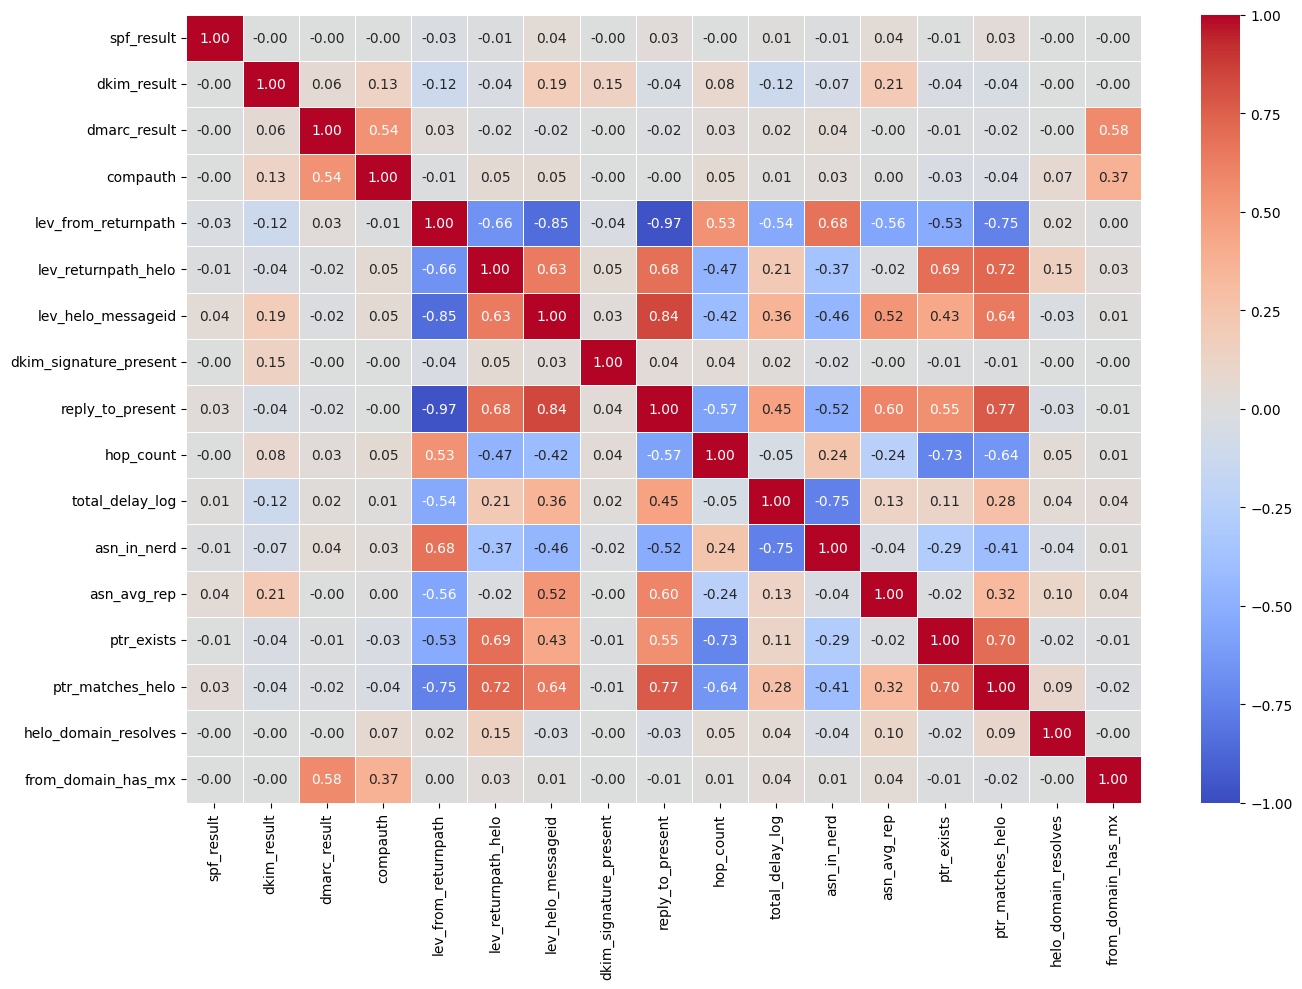

In [5]:
pearson_matrix = train_df.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_matrix,
    annot=True,       
    fmt=".2f",    
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5   
)
plt.tight_layout()
plt.show()

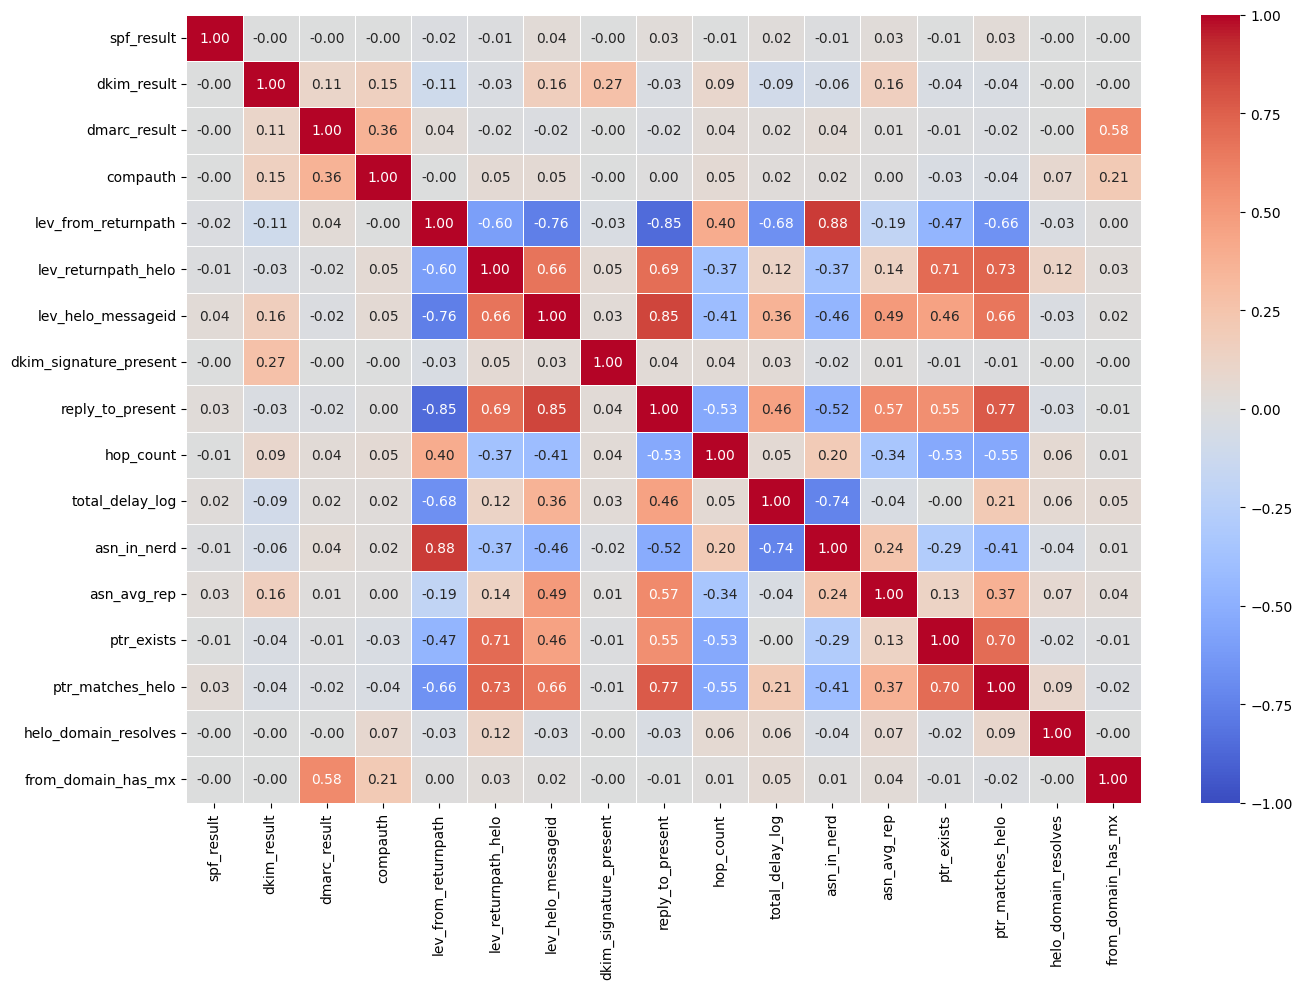

In [6]:
pearson_matrix = train_df.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_matrix,
    annot=True,       
    fmt=".2f",    
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5   
)
plt.tight_layout()
plt.show()

Kaiser Rule: 7 components retained (eigenvalue > 1.0)
Cumulative variance explained: 81.4%


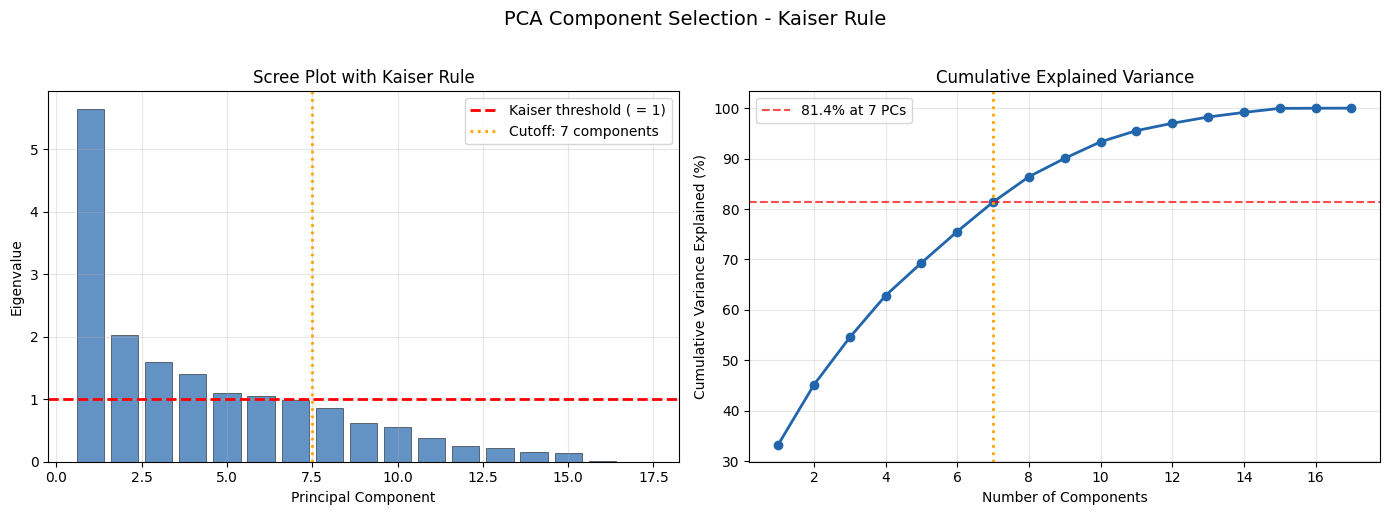


PC    Eigenvalue   Var %      Cumul %    Keep? 
---------------------------------------------
PC1   5.6489       33.22      33.22      y
PC2   2.0235       11.90      45.12      y
PC3   1.6002       9.41       54.53      y
PC4   1.4109       8.30       62.82      y
PC5   1.1043       6.49       69.32      y
PC6   1.0568       6.21       75.53      y
PC7   0.9936       5.84       81.37      
PC8   0.8556       5.03       86.41      
PC9   0.6189       3.64       90.04      
PC10  0.5576       3.28       93.32      
PC11  0.3770       2.22       95.54      
PC12  0.2477       1.46       97.00      
PC13  0.2119       1.25       98.24      
PC14  0.1560       0.92       99.16      
PC15  0.1351       0.79       99.96      
PC16  0.0060       0.04       99.99      
PC17  0.0017       0.01       100.00     


In [7]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)
eigenvalues = pca_full.explained_variance_
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_kaiser = int(np.sum(eigenvalues > 0.9))


print(f"Kaiser Rule: {n_kaiser} components retained (eigenvalue > 1.0)")
print(f"Cumulative variance explained: {cumulative_var[n_kaiser-1]*100:.1f}%")




fig, axes = plt.subplots(1, 2, figsize=(14, 5))




axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues,

            color='#2166ac', alpha=0.7, edgecolor='k', linewidth=0.5)

axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=2,

                label='Kaiser threshold ( = 1)')

axes[0].axvline(x=n_kaiser + 0.5, color='orange', linestyle=':',

                linewidth=2, label=f'Cutoff: {n_kaiser} components')

axes[0].set_xlabel('Principal Component')

axes[0].set_ylabel('Eigenvalue')

axes[0].set_title('Scree Plot with Kaiser Rule')

axes[0].legend()

axes[0].grid(True, alpha=0.3)



axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,

             'o-', color='#2166ac', linewidth=2)

axes[1].axhline(y=cumulative_var[n_kaiser-1]*100, color='red',

                linestyle='--', alpha=0.7,

                 label=f'{cumulative_var[n_kaiser-1]*100:.1f}% at {n_kaiser} PCs')

axes[1].axvline(x=n_kaiser, color='orange', linestyle=':', linewidth=2)

axes[1].set_xlabel('Number of Components')

axes[1].set_ylabel('Cumulative Variance Explained (%)')

axes[1].set_title('Cumulative Explained Variance')

axes[1].legend()

axes[1].grid(True, alpha=0.3)



plt.suptitle('PCA Component Selection - Kaiser Rule', fontsize=14, y=1.02)

plt.tight_layout()

plt.show()




print(f"\n{'PC':<5} {'Eigenvalue':<12} {'Var %':<10} {'Cumul %':<10} {'Keep?':<6}")

print("-" * 45)

for i in range(len(eigenvalues)):

    keep = "y" if eigenvalues[i] > 1.0 else ""

    print(f"PC{i+1:<3} {eigenvalues[i]:<12.4f} "

          f"{pca_full.explained_variance_ratio_[i]*100:<10.2f} "

          f"{cumulative_var[i]*100:<10.2f} {keep}")

In [8]:
pca = PCA(n_components=n_kaiser, random_state=42)

X_train_shap = X_train.copy()
X_scam_shap = X_test_scam.copy()
X_legit_shap = X_test_legit.copy()
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)


print(f"\nPCA applied: {no_features} features -> {n_kaiser} components")
print(f"Variance retained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"X_train shape: {X_train.shape}")


PCA applied: 17 features -> 7 components
Variance retained: 81.4%
X_train shape: (2984, 7)


In [9]:
X_test_legit = X_test[y_test == 0]
X_test_scam  = X_test[y_test == 1]

In [10]:
best_psi = 256
best_t = 100
if_final = IsolationForest(n_estimators=best_t, max_samples=best_psi, random_state=42, contamination='auto')
if_final.fit(X_train)
scores_train = get_anomaly_scores(if_final, X_train) 
p90 = np.percentile(scores_train, 90)
final_threshold = p90
print(f"Threshold: {final_threshold:.6f}")

Threshold: 0.531252


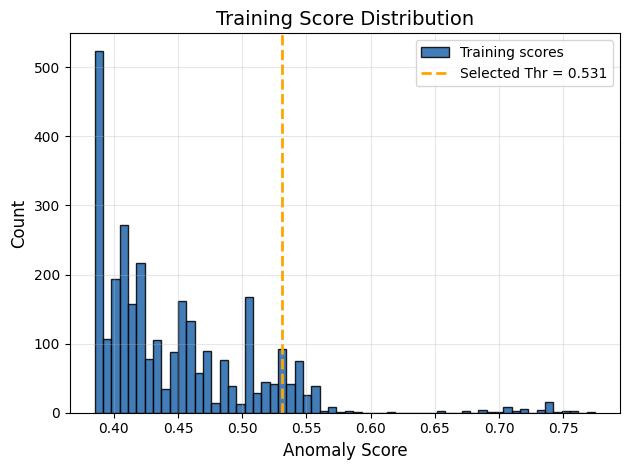

In [11]:
plt.hist(
    scores_train, bins=60,
    color='#2166ac', alpha=0.85,
    edgecolor='k',
    label=f'Training scores'
)

plt.axvline(
    p90, color='orange', linestyle='--', linewidth=2,
    label=f'Selected Thr = {p90:.3f}'
)

plt.title("Training Score Distribution", fontsize=14)
plt.xlabel("Anomaly Score", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

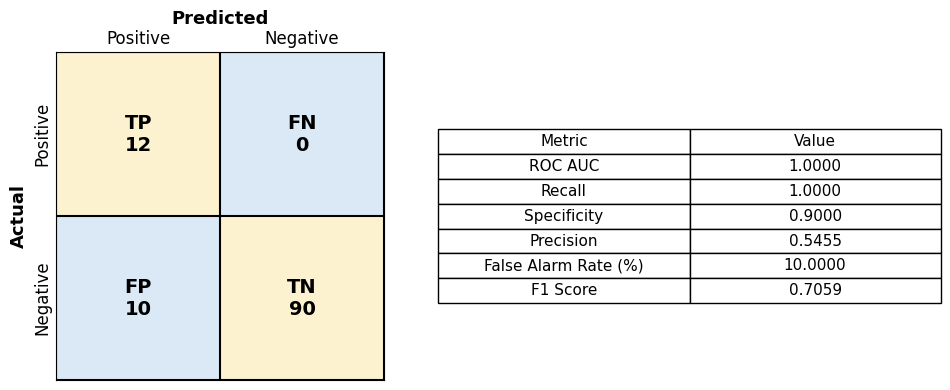

In [12]:
scores_test = get_anomaly_scores(if_final, X_test) 
scores_legit = scores_test[y_test == 0] 
scores_scam = scores_test[y_test == 1] 

pl_legit = path_lengths(if_final, X_test_legit) 
pl_scam = path_lengths(if_final, X_test_scam) 
pl_train = path_lengths(if_final, X_train) 
preds_final = (scores_test > final_threshold).astype(int) 

tp = ((preds_final==1)&(y_test==1)).sum() 
fp = ((preds_final==1)&(y_test==0)).sum() 
tn = ((preds_final==0)&(y_test==0)).sum() 
fn = ((preds_final==0)&(y_test==1)).sum() 

roc_auc = roc_auc_score(y_test, scores_test) 
recall = tp/(tp+fn) if (tp+fn) else 0 
specificity = tn/(tn+fp) if (tn+fp) else 0 
far = fp/(fp+tn) if (fp+tn) else 0 
precision = tp/(tp+fp) if (tp+fp) else 0 
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0

fig, (ax1, ax2) = plt.subplots( 1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.2, 1]} )
cmap = mcolors.ListedColormap(['#dbe9f6', '#fdf2d0'])

ax1.imshow([[1, 0], [0, 1]], cmap=cmap, aspect='equal')

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])

ax1.set_xticklabels(['Positive', 'Negative'], fontsize=12)
ax1.set_yticklabels(['Positive', 'Negative'], fontsize=12, rotation=90, va="center")

ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=13, fontweight='bold')

labels = [["TP", "FN"],
          ["FP", "TN"]]

cm = np.array([[tp, fn],
               [fp, tn]])

for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                 ha="center", va="center",
                 fontsize=14, fontweight='bold')

ax1.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax1.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax1.grid(which='minor', color='black', linewidth=1.5)
ax1.tick_params(which='both', length=0)


df_metrics = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Recall",
        "Specificity",
        "Precision",
        "False Alarm Rate (%)",
        "F1 Score"
    ],
    "Value": [
        roc_auc,
        recall,
        specificity,
        precision,
        far * 100,
        f1
    ]
})

df_metrics["Value"] = df_metrics["Value"].map(lambda x: f"{x:.4f}")

ax2.axis("off")

table = ax2.table(
    cellText=df_metrics.values,
    colLabels=df_metrics.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.4)

plt.tight_layout()
plt.show()

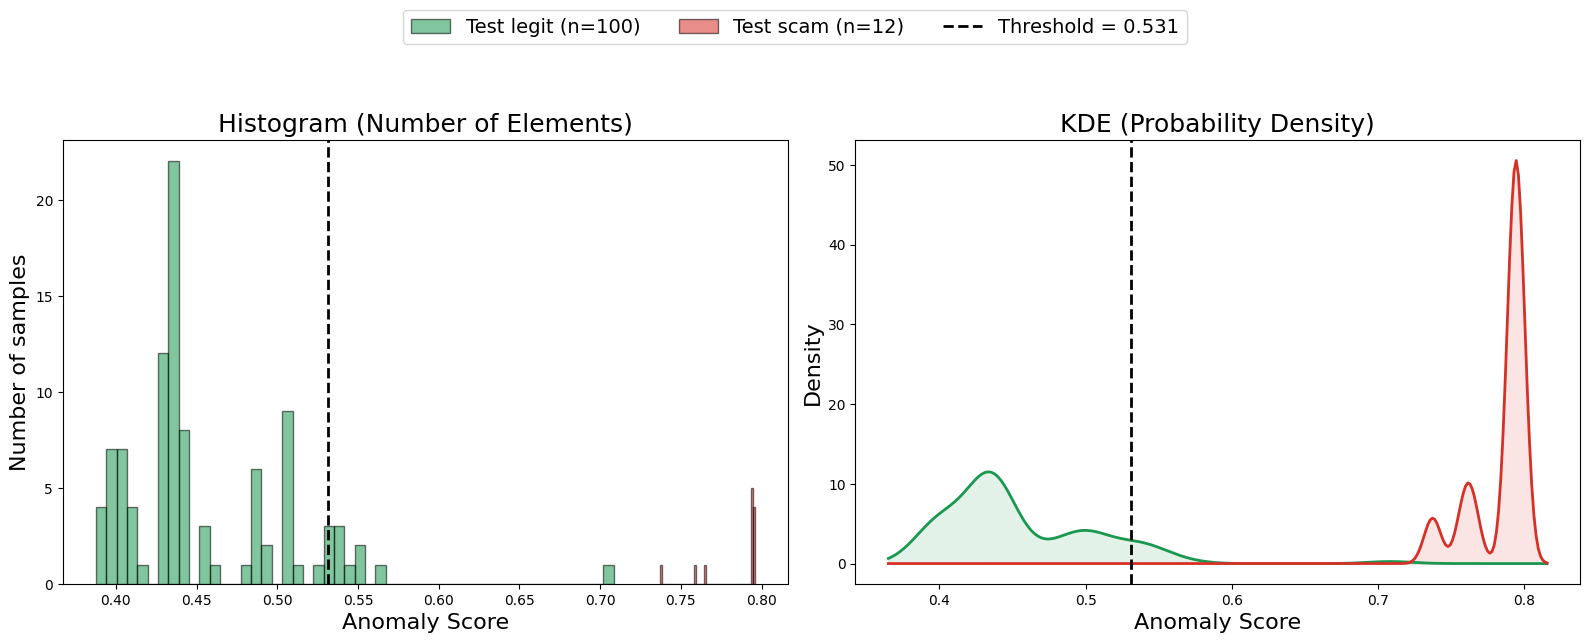

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, mode in [(axes[0], 'hist'), (axes[1], 'kde')]:

    if mode == 'hist':

        ax.hist(
            scores_legit,
            bins=50,
            alpha=.55,
            density=False,
            color='#1a9850',
            edgecolor='k',
            lw=.3,
            label=f'Test legit (n={len(scores_legit)})'
        )

        ax.hist(
            scores_scam,
            bins=50,
            alpha=.55,
            density=False,
            color='#d73027',
            edgecolor='k',
            lw=.3,
            label=f'Test scam (n={len(scores_scam)})'
        )

        ax.set_title('Histogram (Number of Elements)', fontsize=18)
        ax.set_ylabel('Number of samples', fontsize=16)

    else:

        lo = min(scores_train.min(),
                 scores_legit.min(),
                 scores_scam.min()) - .02

        hi = max(scores_train.max(),
                 scores_legit.max(),
                 scores_scam.max()) + .02

        xs = np.linspace(lo, hi, 300)

        for d, lb, c in [
            # (scores_train, 'Train legit', '#2166ac'),
            (scores_legit, 'Test legit', '#1a9850'),
            (scores_scam,  'Test scam',  '#d73027')
        ]:
            k = gaussian_kde(d, bw_method=.3)
            ax.plot(xs, k(xs), lw=2, c=c, label=lb)
            ax.fill_between(xs, k(xs), alpha=.12, color=c)

        ax.set_title('KDE (Probability Density)', fontsize=18)
        ax.set_ylabel('Density', fontsize=16)
    ax.axvline(
        final_threshold,
        color='k',
        ls='--',
        lw=2,
        label=f'Threshold = {final_threshold:.3f}'
    )

    ax.set_xlabel('Anomaly Score', fontsize=16)
    # ax.legend(fontsize=14)
    # ax.grid(True, alpha=.3)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    bbox_to_anchor=(0.5, 1.08)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.tight_layout()
plt.show()

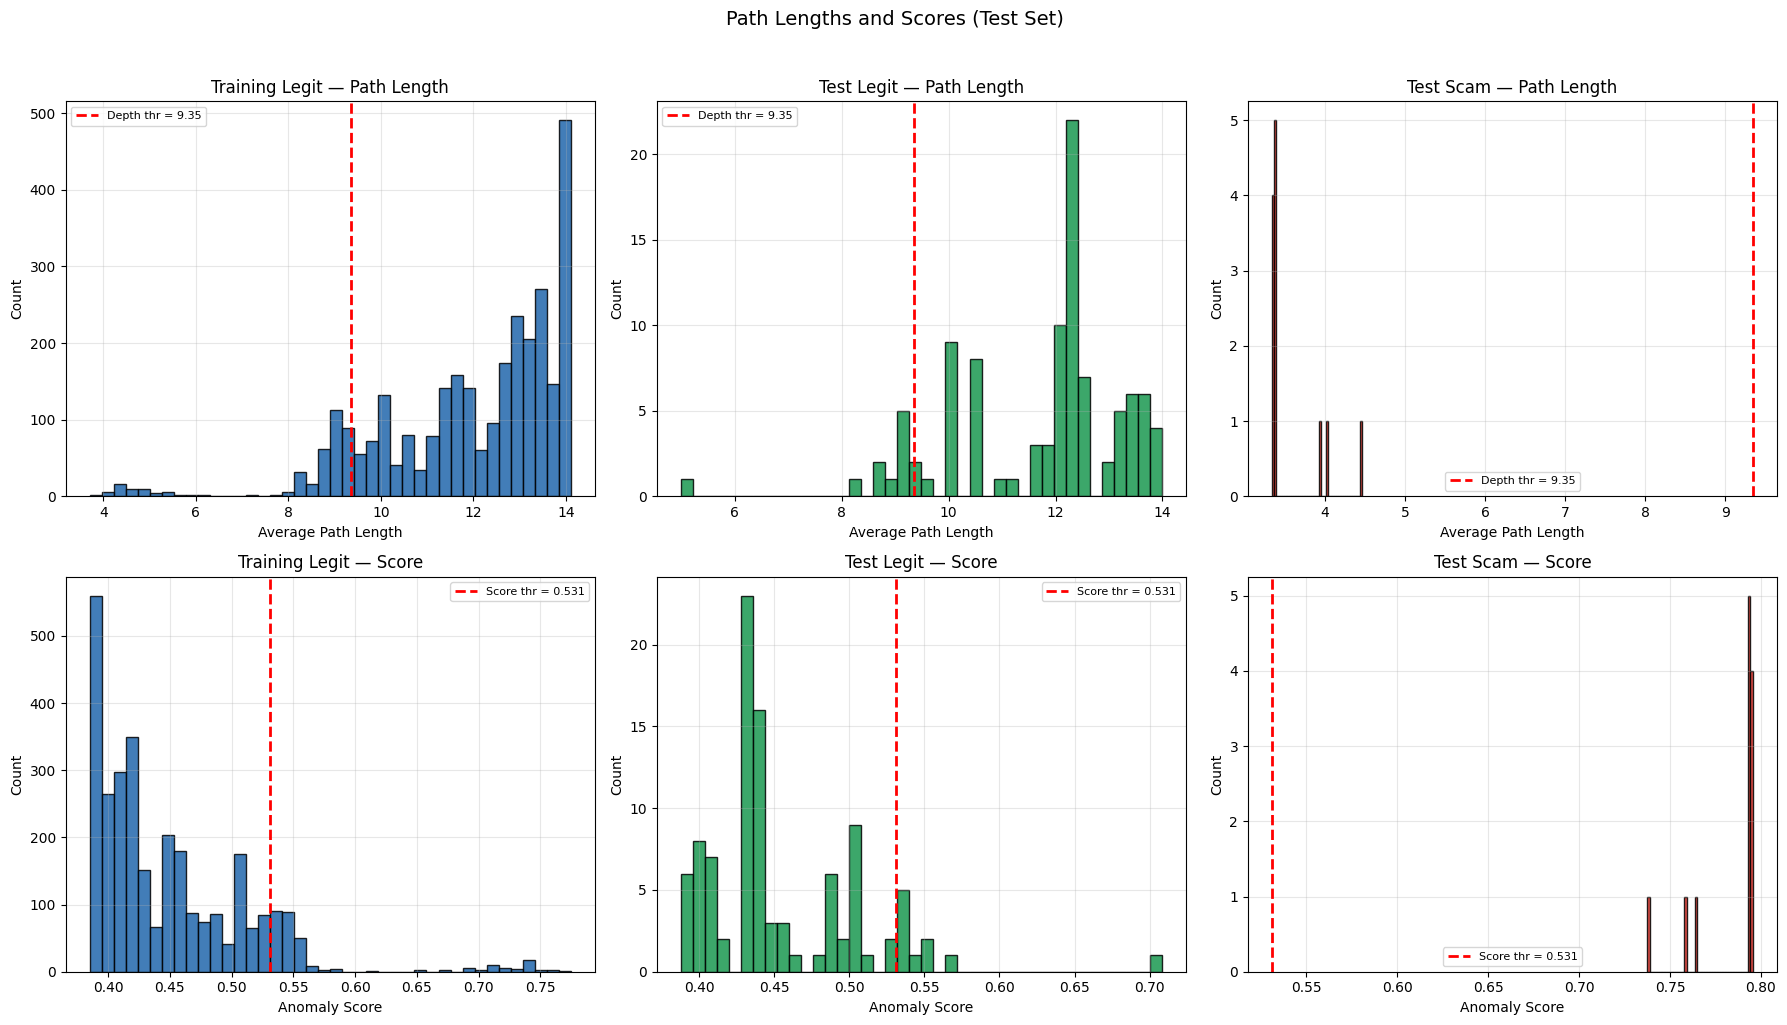

In [14]:
c_psi = c_factor(best_psi)
thr_depth = -c_psi * np.log2(final_threshold)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
datasets = [(pl_train, scores_train, 'Training Legit',    '#2166ac'),
            (pl_legit, scores_legit,  'Test Legit',  '#1a9850'),
            (pl_scam,  scores_scam,   'Test Scam',   '#d73027')]
for col, (pl, sc, lbl, clr) in enumerate(datasets):
    ax = axes[0, col]
    ax.hist(pl, bins=40, color=clr, alpha=.85, edgecolor='k', lw=.3)
    ax.axvline(thr_depth, color='red', ls='--', lw=2, label=f'Depth thr = {thr_depth:.2f}')
    ax.set(xlabel='Average Path Length', ylabel='Count', title=f'{lbl} — Path Length')
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)

    ax = axes[1, col]
    ax.hist(sc, bins=40, color=clr, alpha=.85, edgecolor='k', lw=.3)
    ax.axvline(final_threshold, color='red', ls='--', lw=2, label=f'Score thr = {final_threshold:.3f}')
    ax.set(xlabel='Anomaly Score', ylabel='Count', title=f'{lbl} — Score')
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)
plt.suptitle('Path Lengths and Scores (Test Set)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

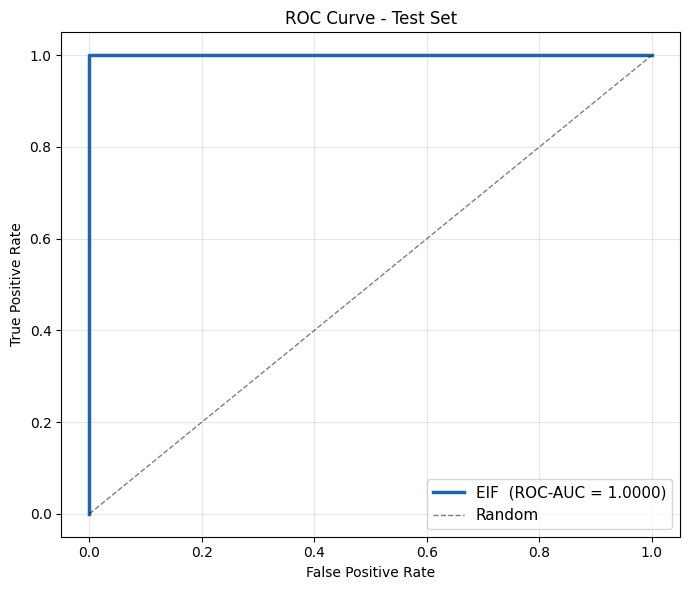

In [15]:
fpr, tpr, _ = roc_curve(y_test, scores_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2.5, color='#2166ac', label=f'EIF  (ROC-AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve - Test Set')
ax.legend(fontsize=11); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

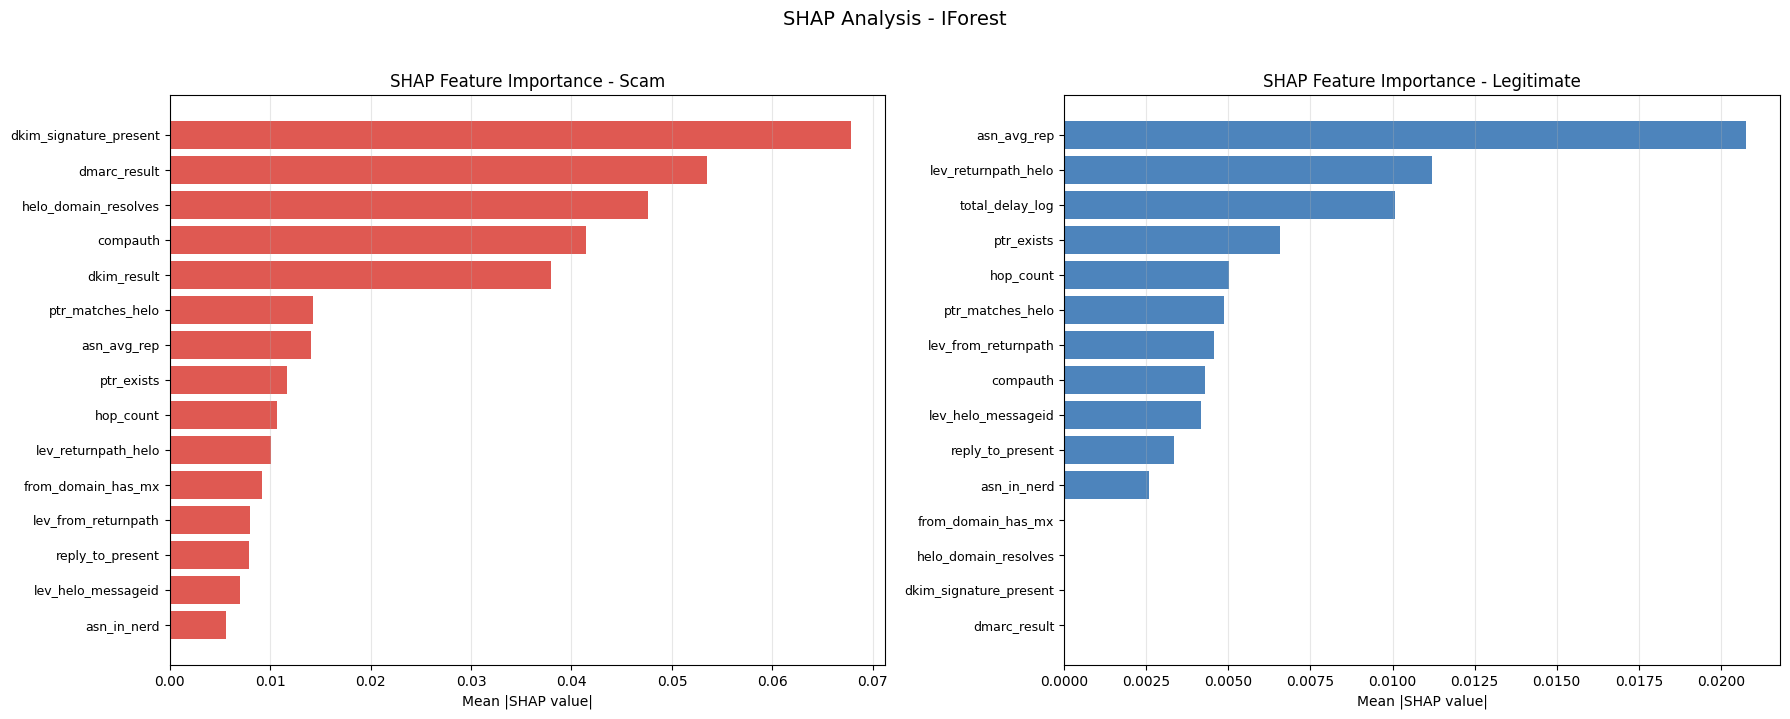

In [16]:
def predict_from_original(X_orig):
    X_pca = pca.transform(X_orig)
    return get_anomaly_scores(if_final, X_pca)

bg_idx = np.random.default_rng(42).choice(X_train_shap.shape[0], 50, replace=False)
explainer = shap.KernelExplainer(predict_from_original, X_train_shap[bg_idx])

n_ex = min(50, len(X_scam_shap), len(X_legit_shap))
scam_idx  = np.random.default_rng(42).choice(len(X_scam_shap),  n_ex, replace=False)
legit_idx = np.random.default_rng(42).choice(len(X_legit_shap), n_ex, replace=False)

sv_scam  = explainer.shap_values(X_scam_shap[scam_idx],  nsamples=80, silent=True)
sv_legit = explainer.shap_values(X_legit_shap[legit_idx], nsamples=80, silent=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, sv, title, clr in [
    (axes[0], sv_scam, 'Scam', '#d73027'),
    (axes[1], sv_legit, 'Legitimate', '#2166ac')
]:
    mi = np.abs(sv).mean(0)
    si = np.argsort(mi)[::-1][:15]
    ax.barh(range(len(si)), mi[si][::-1], color=clr, alpha=.8)
    ax.set_yticks(range(len(si)))
    ax.set_yticklabels([features[i] for i in si][::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'SHAP Feature Importance - {title}')
    ax.grid(True, alpha=.3, axis='x')

plt.suptitle('SHAP Analysis - IForest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()